Trying different type of models for LST estimation

## General paths, libraries and functions

In [1]:
!pip install seaborn
!pip install statsmodels
!pip install rasterstats


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import os
import numpy as np
import rasterio
from rasterio import mask
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from rasterstats import zonal_stats
import joblib


In [2]:
# user-defined paths
base_dir = '../../../datos-notebooks/3.global-data-cba/'
census_areas_name = ''
trained_models_path = '../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/' # modeles trained with HR data
landsat_image = 'LC08_L2SP_229082_20240125_20240130_02_T1'

In [4]:
# inputs

# LST
lst_cropped_path = os.path.join(base_dir, f'LST/LST_cropped_celsius{landsat_image}.tif') # values out of bound are 0
lst_clipped_path = os.path.join(base_dir, f'LST/LST_clipped_celsius{landsat_image}.tif') #values out of bound are nan

# vectors
census_areas_path = os.path.join(base_dir, census_areas_name)
# variables - Best results (pearson correlation with LST) for window size -- same as used in HR data
ndwi_1_path = os.path.join(base_dir, f'land-cover-{landsat_image}/moving-windows/ndwi/Class_1_window7.tif')
ndvi_1_path = os.path.join(base_dir, f'land-cover-{landsat_image}/moving-windows/ndvi/Class_1_window7.tif')
ndvi_0p5_path = os.path.join(base_dir, f'land-cover-{landsat_image}/moving-windows/ndvi/Class_0p5_window9.tif')
veg_vol_path = os.path.join(base_dir, f'objects-height/moving-windows/tree-volume/trees_window15.tif')
veg_height_path = os.path.join(base_dir, f'objects-height/moving-windows/tree-height/trees_height_window15.tif')
built_vol_path = os.path.join(base_dir, 'objects-height/moving-windows/building-volume/buildings_window13.tif')
built_area_path = os.path.join(base_dir, 'objects-height/moving-windows/building-area/building_area_window3.tif')
building_height_path = os.path.join(base_dir, 'objects-height/moving-windows/building-height/building_height_window3.tif')
mean_elev_path = os.path.join(base_dir, 'topography/moving_windows/elev_mean/elev_mean_win111.tif')
mean_slope_path = os.path.join(base_dir, 'topography/moving_windows/slope_mean/slope_mean_win101.tif')
northness_path = os.path.join(base_dir, 'topography/moving_windows/northness/northness_win37.tif')

# output directorys
lst_prediction_folder = os.path.join(base_dir, 'LST-prediction/')
os.makedirs(lst_prediction_folder, exist_ok=True)
standarized_folder_path = os.path.join(lst_prediction_folder, 'standarized_variables')


In [5]:
def stepwise_selection_aic(X, y, initial_list=None, min_delta=5, verbose=True):
    """
    Forward-backward stepwise selection based on AIC.
    """
    if initial_list is None:
        included = []
    else:
        included = list(initial_list)

    # Fit initial model (if any)
    if included:
        model = sm.OLS(y, sm.add_constant(X[included])).fit()
        current_aic = model.aic
    else:
        current_aic = np.inf

    while True:
        changed = False

        # ---------- Forward step ----------
        excluded = list(set(X.columns) - set(included))
        best_candidate = None
        best_aic = current_aic

        for col in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [col]])).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_candidate = col

        if best_candidate is not None and (current_aic - best_aic) > min_delta:
            included.append(best_candidate)
            current_aic = best_aic
            changed = True
            if verbose:
                print(f"Add {best_candidate:30} AIC = {best_aic:.2f}")

        # ---------- Backward step ----------
        if included:
            worst_candidate = None
            best_aic_back = current_aic

            for col in included:
                temp = included.copy()
                temp.remove(col)
                if temp:
                    model = sm.OLS(y, sm.add_constant(X[temp])).fit()
                    if model.aic < best_aic_back:
                        best_aic_back = model.aic
                        worst_candidate = col

            if worst_candidate is not None and (current_aic - best_aic_back) > min_delta:
                included.remove(worst_candidate)
                current_aic = best_aic_back
                changed = True
                if verbose:
                    print(f"Drop {worst_candidate:30} AIC = {best_aic_back:.2f}")

        if not changed:
            break

    return included


## Dataset preparation

### mask rasters to city boundary

In [6]:
with rasterio.open(lst_clipped_path) as src:
    lst = src.read(1)

lst_mask = np.isnan(lst)

# mask values out of city boundary
ndwi_1 = np.where(lst_mask, np.nan, rasterio.open(ndwi_1_path).read(1).astype("float32"))
ndvi_1 = np.where(lst_mask, np.nan, rasterio.open(ndvi_1_path).read(1).astype("float32"))
ndvi_0p5 = np.where(lst_mask, np.nan, rasterio.open(ndvi_0p5_path).read(1).astype("float32"))
veg_vol = np.where(lst_mask, np.nan, rasterio.open(veg_vol_path).read(1).astype("float32"))
built_vol = np.where(lst_mask, np.nan, rasterio.open(built_vol_path).read(1).astype("float32"))
built_area = np.where(lst_mask, np.nan, rasterio.open(built_area_path).read(1).astype("float32"))
built_height = np.where(lst_mask, np.nan, rasterio.open(building_height_path).read(1).astype("float32"))
mean_elev = np.where(lst_mask, np.nan, rasterio.open(mean_elev_path).read(1).astype("float32"))
mean_slope = np.where(lst_mask, np.nan, rasterio.open(mean_slope_path).read(1).astype("float32"))
northness = np.where(lst_mask, np.nan, rasterio.open(northness_path).read(1).astype("float32"))
veg_height = np.where(lst_mask, np.nan, rasterio.open(veg_height_path).read(1).astype("float32"))

rasters_masked = {
    #"Water": ndwi_1,
    "Vegetación densa": ndvi_1,
    "Vegetación dispersa": ndvi_0p5,
    #"Volumen de vegetación": veg_vol,
    #"Volumen construido": built_vol,
    "Área construida": built_area,
    "Altura de edificación": built_height,
    #"Elevation": mean_elev,
    "Pendiente": mean_slope,
    #"Orientación norte": northness,
    "Altura de vegetación": veg_height
}



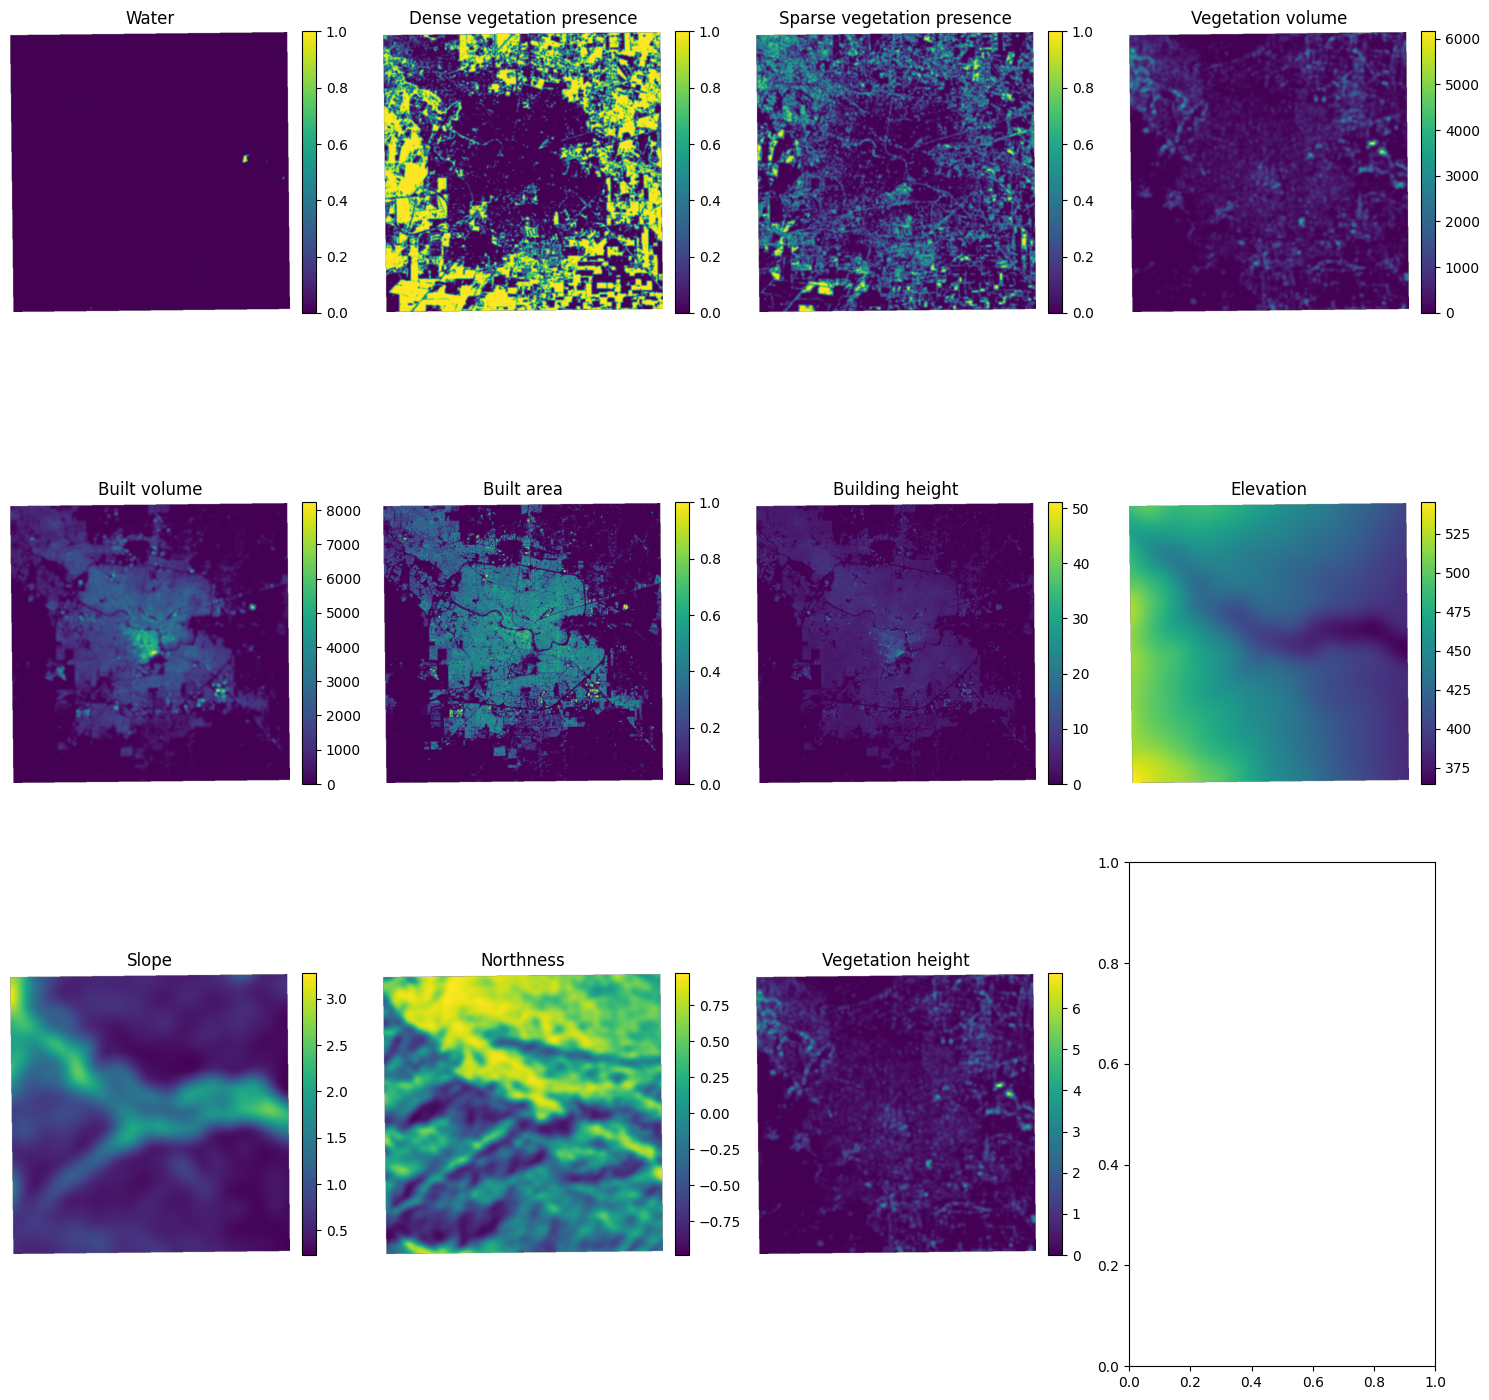

In [7]:
#plot masked rasters 

fig, axes = plt.subplots(3, 4, figsize=(15, 15))

for ax, (name, data) in zip(axes.flat, rasters_masked.items()):

    img = ax.imshow(data, cmap='viridis')
    ax.set_title(name)
    ax.axis('off')
    fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)


plt.tight_layout()
plt.show()

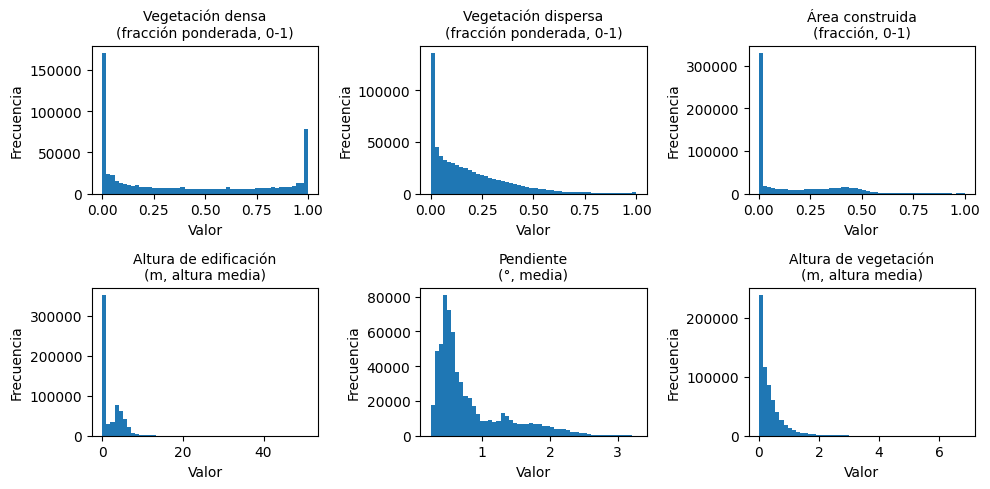

In [13]:
# Plot histograms of masked rasters
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
axes = axes.flatten()

titles = {
    "Vegetación densa": "Vegetación densa\n(fracción ponderada, 0-1)",
    "Vegetación dispersa": "Vegetación dispersa\n(fracción ponderada, 0-1)",
    "Área construida": "Área construida\n(fracción, 0-1)",
    "Altura de edificación": "Altura de edificación\n(m, altura media)",
    "Pendiente": "Pendiente\n(°, media)",
    "Altura de vegetación": "Altura de vegetación\n(m, altura media)",
}

for i, (name, arr) in enumerate(rasters_masked.items()):
    axes[i].hist(arr[~np.isnan(arr)], bins=50)
    axes[i].set_title(titles[name], fontsize=10)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### standarize variables - mean:0, std:1

In [9]:
os.makedirs(standarized_folder_path, exist_ok=True)

In [10]:
# Z-score standardization for regression predictors

def standardize_array(arr, profile, out_path):
    mean = np.nanmean(arr)
    std = np.nanstd(arr)
    z = (arr - mean) / std

    profile.update(dtype='float32')

    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(z.astype('float32'), 1)

In [11]:
# Apply standarization
with rasterio.open(lst_clipped_path) as src:
    profile = src.profile.copy()
    
standardize_array(ndwi_1, profile, os.path.join(standarized_folder_path, 'NDWI_1_z.tif'))
standardize_array(ndvi_1, profile, os.path.join(standarized_folder_path, 'NDVI_1_z.tif'))
standardize_array(ndvi_0p5, profile, os.path.join(standarized_folder_path, 'NDVI_0p5_z.tif'))
standardize_array(veg_vol, profile, os.path.join(standarized_folder_path, 'VEG_VOL_z.tif'))
standardize_array(built_vol, profile, os.path.join(standarized_folder_path, 'BUILT_VOL_z.tif'))
standardize_array(built_area, profile, os.path.join(standarized_folder_path, 'BUILT_AREA_z.tif'))
standardize_array(built_height, profile, os.path.join(standarized_folder_path, 'BUILDING_HEIGHT_z.tif'))
standardize_array(mean_elev, profile, os.path.join(standarized_folder_path, 'ELEV_z.tif'))
standardize_array(mean_slope, profile, os.path.join(standarized_folder_path, 'SLOPE_z.tif'))
standardize_array(northness, profile, os.path.join(standarized_folder_path, 'NORTH_z.tif'))
standardize_array(veg_height, profile, os.path.join(standarized_folder_path, 'VEG_HEIGHT_z.tif'))

In [17]:
std_rasters_paths = {
    #"Agua": os.path.join(standarized_folder_path, "NDWI_1_z.tif"),
    "Vegetación densa": os.path.join(standarized_folder_path, "NDVI_1_z.tif"),
    "Vegetación dispersa": os.path.join(standarized_folder_path, "NDVI_0p5_z.tif"),
    "Altura de vegetación": os.path.join(standarized_folder_path, "VEG_HEIGHT_z.tif"),
    #"Volumen de vegetación": os.path.join(standarized_folder_path, "VEG_VOL_z.tif"),
    #"Volumen construido": os.path.join(standarized_folder_path, "BUILT_VOL_z.tif"),  # Excluido para evitar duplicación de información
    "Área construida": os.path.join(standarized_folder_path, "BUILT_AREA_z.tif"),
    "Altura de edificación": os.path.join(standarized_folder_path, "BUILDING_HEIGHT_z.tif"),
    #"Elevación": os.path.join(standarized_folder_path, "ELEV_z.tif"),
    "Pendiente": os.path.join(standarized_folder_path, "SLOPE_z.tif"),
    #"Orientación norte": os.path.join(standarized_folder_path, "NORTH_z.tif")
}

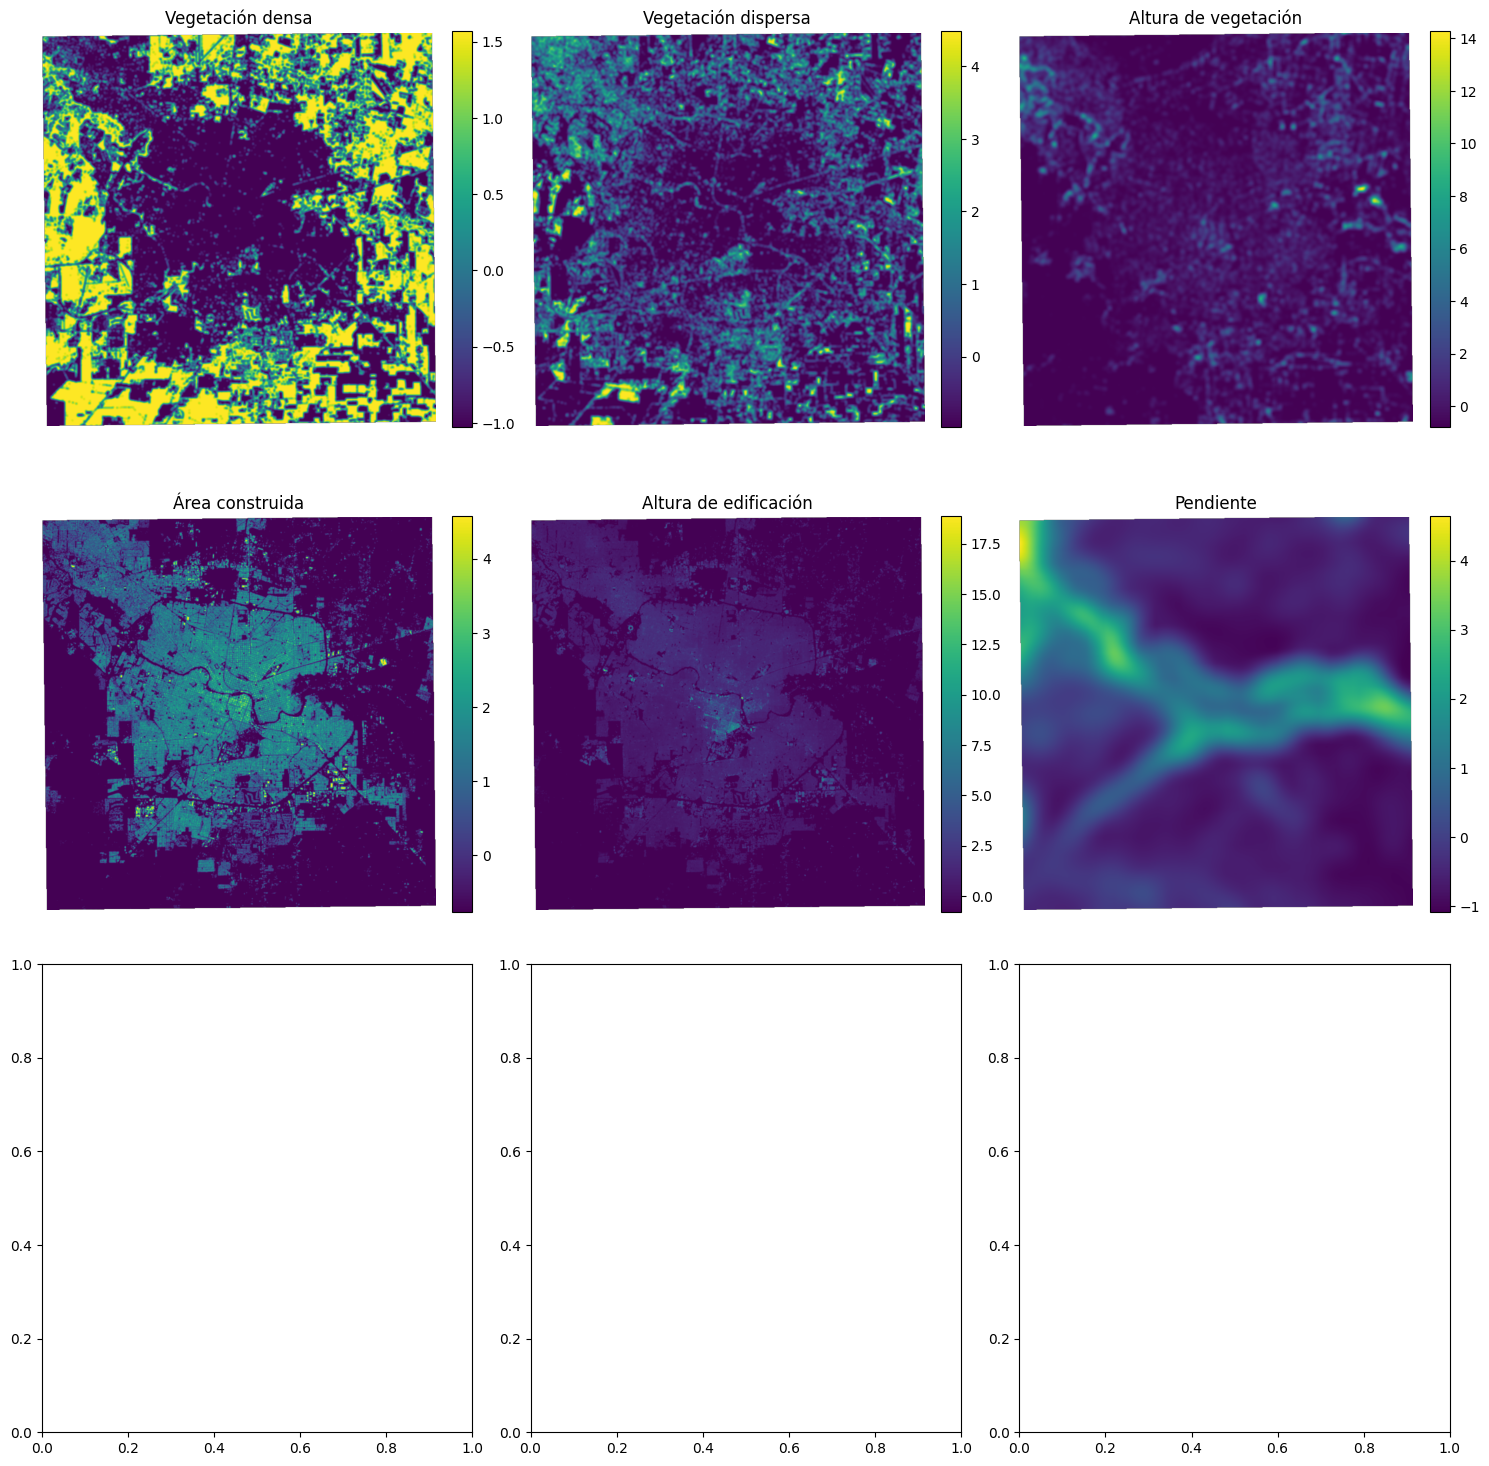

In [13]:
#plot cropped and standardized rasters

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, (name, path) in zip(axes.flat, std_rasters_paths.items()):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)

    img = ax.imshow(data, cmap='viridis')
    ax.set_title(name)
    ax.axis('off')
    fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)


plt.tight_layout()
plt.show()

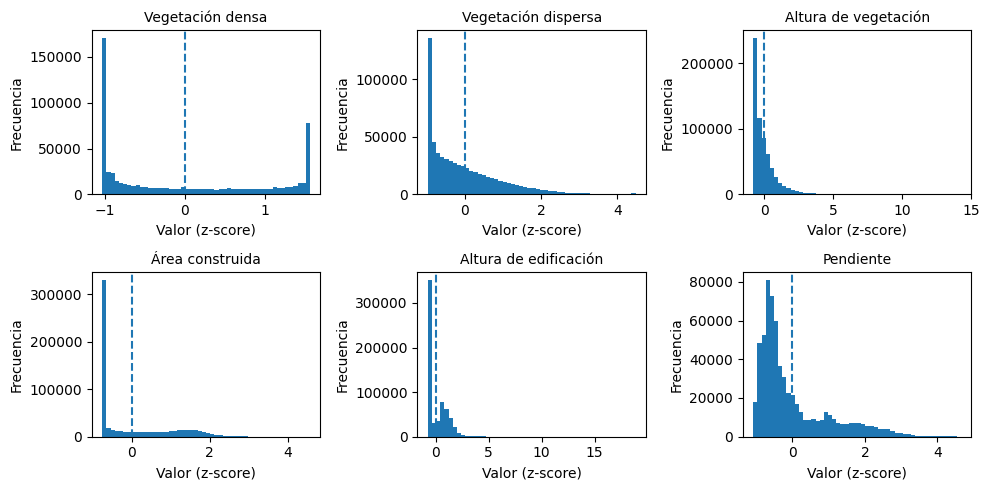

In [22]:
# plot histograms of standardized rasters

fig, axes = plt.subplots(2, 3, figsize=(10, 5))
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, (name, path) in enumerate(std_rasters_paths.items()):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata

    # Plot histogram
    axes[i].hist(arr[~np.isnan(arr)], bins=50)
    axes[i].set_title(name, fontsize=10)
    axes[i].set_xlabel("Valor (z-score)")
    axes[i].set_ylabel("Frecuencia")
    axes[i].axvline(0, linestyle='--')


plt.tight_layout()
plt.show()

### stratified sampling of LST

In [15]:
rasters = {"LST": lst_clipped_path} # create dictionary with LST raster 
rasters.update(std_rasters_paths) # add standardized rasters to the dictionary
#rasters.pop("Variable name", None) # to delete one variable if needed

In [16]:
rasters

{'LST': '../../../datos-notebooks/3.global-data-cba/LST/LST_clipped_celsiusLC08_L2SP_229082_20240125_20240130_02_T1.tif',
 'Vegetación densa': '../../../datos-notebooks/3.global-data-cba/LST-prediction/standarized_variables\\NDVI_1_z.tif',
 'Vegetación dispersa': '../../../datos-notebooks/3.global-data-cba/LST-prediction/standarized_variables\\NDVI_0p5_z.tif',
 'Altura de vegetación': '../../../datos-notebooks/3.global-data-cba/LST-prediction/standarized_variables\\VEG_HEIGHT_z.tif',
 'Área construida': '../../../datos-notebooks/3.global-data-cba/LST-prediction/standarized_variables\\BUILT_AREA_z.tif',
 'Altura de edificación': '../../../datos-notebooks/3.global-data-cba/LST-prediction/standarized_variables\\BUILDING_HEIGHT_z.tif',
 'Pendiente': '../../../datos-notebooks/3.global-data-cba/LST-prediction/standarized_variables\\SLOPE_z.tif'}

In [17]:
# Create bins
n_bins = 10

# Read and flatten
data_arrays = {}
for name, path in rasters.items():
    with rasterio.open(path) as src:
        arr = src.read(1)
        data_arrays[name] = arr.flatten()

df = pd.DataFrame(data_arrays)

df = df.dropna() # Drop rows with NaN

df['LST_bin'] = pd.qcut(df['LST'], n_bins, labels=False) # Create LST bins for stratification 

In [18]:
# Stratified sampling: 10% of each bin

sample_fraction = 0.1
df_sampled = df.groupby('LST_bin', group_keys=False).apply(
    lambda x: x.sample(frac=sample_fraction, random_state=42)
)

# Drop bin column
df_sampled = df_sampled.drop(columns=['LST_bin']).reset_index(drop=True)

print(df_sampled.head())


         LST  Vegetación densa  Vegetación dispersa  Altura de vegetación  \
0  32.812313          1.538610            -0.870129             -0.268987   
1  32.894348          1.567370            -0.974998             -0.784811   
2  32.689266          1.567370            -0.974998             -0.777730   
3  32.996887          1.320238            -0.518921              0.314981   
4  32.867004          0.957644            -0.309634              1.892256   

   Área construida  Altura de edificación  Pendiente  
0        -0.759874              -0.776321  -0.890032  
1        -0.759874              -0.776321   0.152303  
2        -0.759874              -0.776321   0.018964  
3        -0.759874              -0.776321  -0.632384  
4        -0.759874              -0.776321  -0.577080  


C:\Users\guada\AppData\Local\Temp\ipykernel_27324\4163941717.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('LST_bin', group_keys=False).apply(


In [19]:
# Show min, max and count of LST values in each bin

df_sampled['LST_bin'] = pd.qcut(df_sampled['LST'], n_bins, labels=False) # Recreate bins for the sampled dataset

for b in range(n_bins):
    values_in_bin = df_sampled[df_sampled['LST_bin'] == b]['LST']
    print(f"Bin {b}: min = {values_in_bin.min():.2f}, max = {values_in_bin.max():.2f}, count = {len(values_in_bin)}")

df_sampled = df_sampled.drop(columns=['LST_bin'])

Bin 0: min = 22.77, max = 33.13, count = 6402
Bin 1: min = 33.13, max = 34.07, count = 6392
Bin 2: min = 34.07, max = 34.63, count = 6420
Bin 3: min = 34.63, max = 35.02, count = 6393
Bin 4: min = 35.03, max = 35.38, count = 6385
Bin 5: min = 35.38, max = 35.75, count = 6397
Bin 6: min = 35.75, max = 36.21, count = 6381
Bin 7: min = 36.21, max = 36.89, count = 6397
Bin 8: min = 36.90, max = 38.15, count = 6402
Bin 9: min = 38.15, max = 47.22, count = 6387


### Descriptive statistics

In [20]:
# Split features and target
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

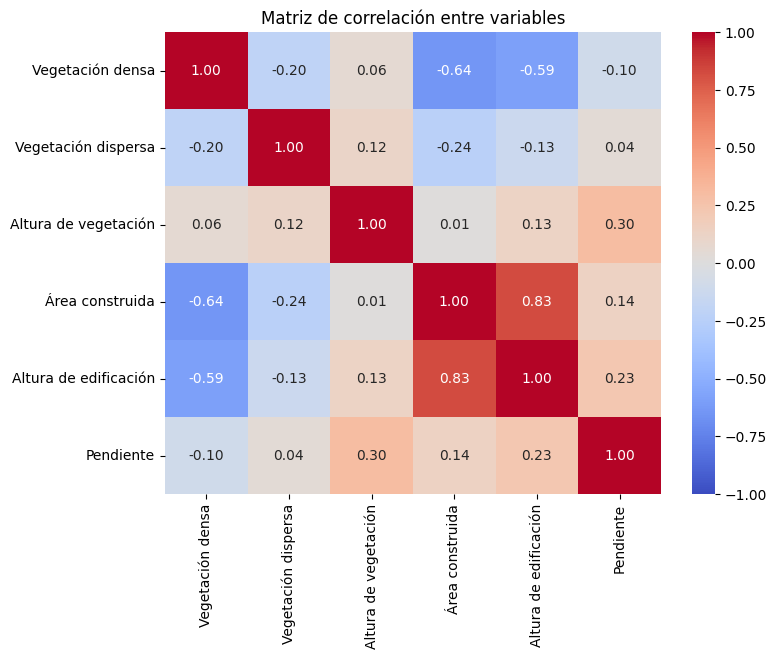

In [21]:
# Compute correlation matrix (only features)
corr_matrix = X.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación entre variables")
plt.show()


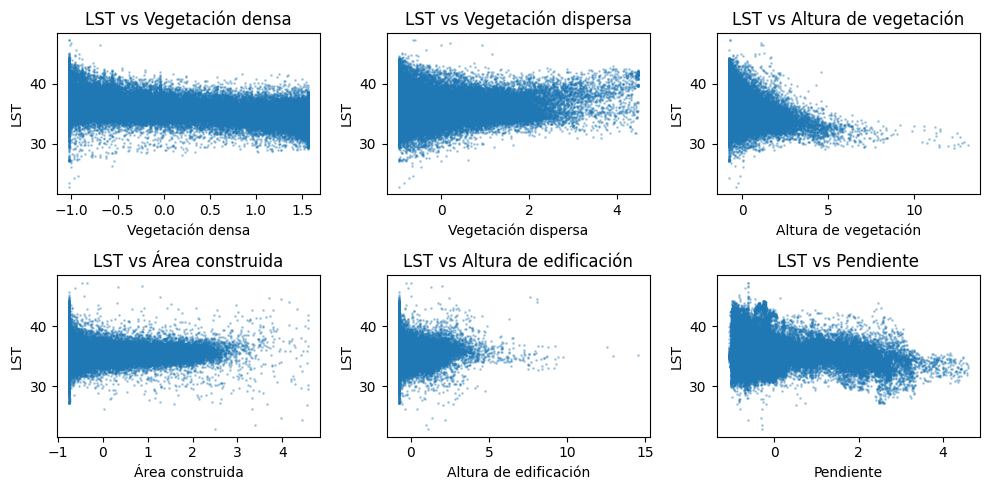

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
axes = axes.flatten() 

for i, v in enumerate(X.columns):
    axes[i].scatter(X[v], y, s=1, alpha=0.3)
    axes[i].set_xlabel(v)
    axes[i].set_ylabel("LST")
    axes[i].set_title(f"LST vs {v}")


plt.tight_layout()
plt.show()

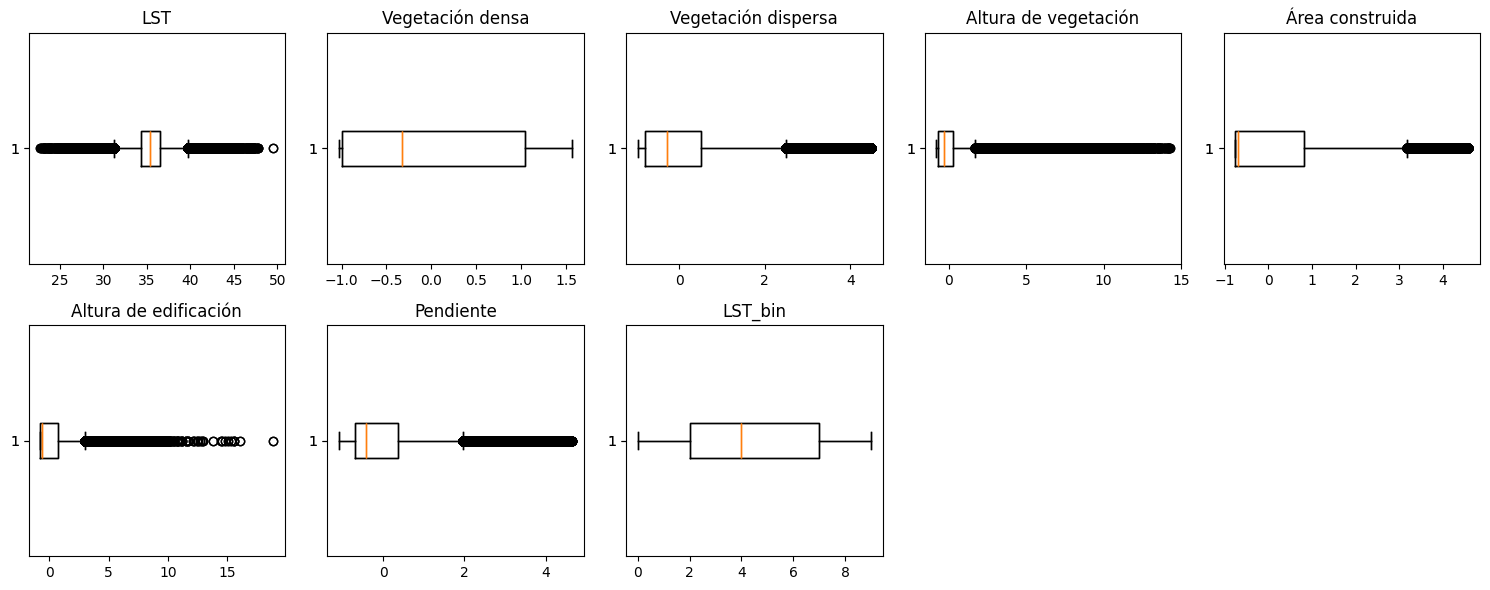

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, v in enumerate(df.columns[:10]):
    axes[i].boxplot(df[v], vert=False)
    axes[i].boxplot(df[v], vert=False)
    axes[i].set_title(v)

for ax in axes[len(df.columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


### PCA

In [24]:
df_sampled

,LST,Vegetación densa,Vegetación dispersa,Altura de vegetación,Área construida,Altura de edificación,Pendiente
0,32.812313,1.538610,-0.870129,-0.268987,-0.759874,-0.776321,-0.890032
1,32.894348,1.567370,-0.974998,-0.784811,-0.759874,-0.776321,0.152303
2,32.689266,1.567370,-0.974998,-0.777730,-0.759874,-0.776321,0.018964
3,32.996887,1.320238,-0.518921,0.314981,-0.759874,-0.776321,-0.632384
4,32.867004,0.957644,-0.309634,1.892256,-0.759874,-0.776321,-0.577080
...,...,...,...,...,...,...,...
63951,38.182022,-0.059523,0.408942,-0.599317,-0.759874,-0.776321,0.157309
63952,41.374454,-1.028546,-0.974998,-0.750457,-0.759874,-0.776321,-0.979727
63953,39.641518,-0.647327,2.578953,0.533416,-0.759874,-0.776321,-0.134224
63954,40.379810,-1.028546,-0.974998,-0.797717,-0.759874,-0.776321,-0.971496


In [25]:
y = df_sampled["LST"].values
X = df_sampled.drop(columns=["LST"])

In [26]:
X

,Vegetación densa,Vegetación dispersa,Altura de vegetación,Área construida,Altura de edificación,Pendiente
0,1.538610,-0.870129,-0.268987,-0.759874,-0.776321,-0.890032
1,1.567370,-0.974998,-0.784811,-0.759874,-0.776321,0.152303
2,1.567370,-0.974998,-0.777730,-0.759874,-0.776321,0.018964
3,1.320238,-0.518921,0.314981,-0.759874,-0.776321,-0.632384
4,0.957644,-0.309634,1.892256,-0.759874,-0.776321,-0.577080
...,...,...,...,...,...,...
63951,-0.059523,0.408942,-0.599317,-0.759874,-0.776321,0.157309
63952,-1.028546,-0.974998,-0.750457,-0.759874,-0.776321,-0.979727
63953,-0.647327,2.578953,0.533416,-0.759874,-0.776321,-0.134224
63954,-1.028546,-0.974998,-0.797717,-0.759874,-0.776321,-0.971496


In [27]:
predictor_names = X.columns.tolist()

# Standardization
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_std)


In [28]:
# Save objects for modelling with global data then
joblib.dump(scaler, os.path.join(lst_prediction_folder, "scaler_pca.pkl"))
joblib.dump(pca, os.path.join(lst_prediction_folder, "pca.pkl"))
joblib.dump(predictor_names, os.path.join(lst_prediction_folder, "predictor_names_pca.pkl"))

# for using in another notebook:
'''
import joblib

# Load objects
scaler = joblib.load("scaler.pkl")
pca = joblib.load("pca.pkl")
predictor_names = joblib.load("predictor_names.pkl")

# Apply to new data
X_std = scaler.transform(X)
X_pca = pca.transform(X_std)

'''

'\nimport joblib\n\n# Load objects\nscaler = joblib.load("scaler.pkl")\npca = joblib.load("pca.pkl")\npredictor_names = joblib.load("predictor_names.pkl")\n\n# Apply to new data\nX_std = scaler.transform(X)\nX_pca = pca.transform(X_std)\n\n'

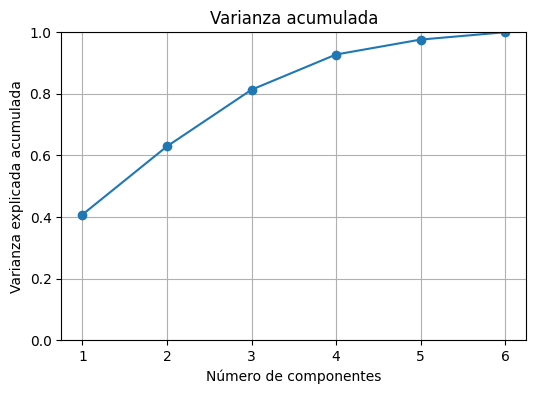

In [29]:
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_)+1),
         np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.ylim(0,1)
plt.title("Varianza acumulada")
plt.grid(True)
plt.show()

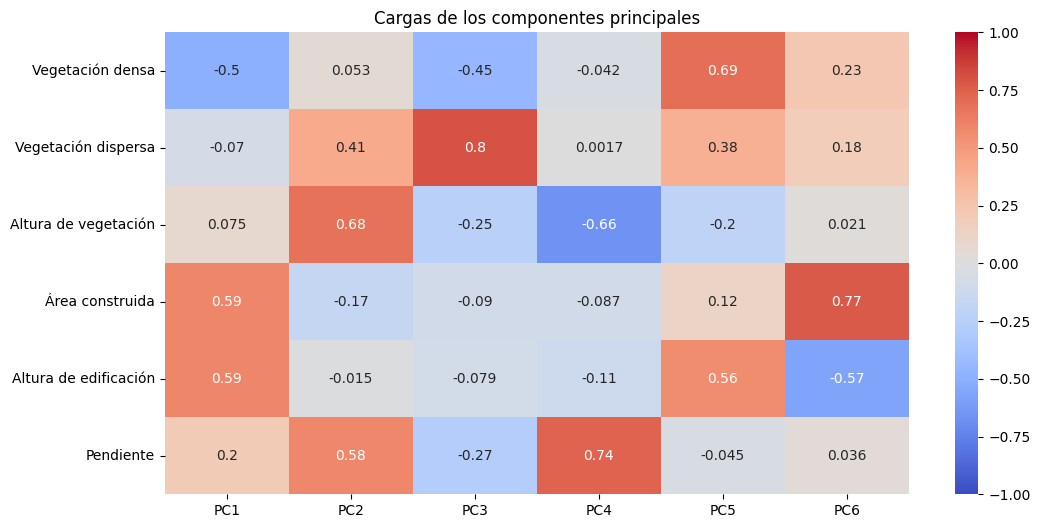

In [30]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(X.shape[1])],
    index=predictor_names
)

plt.figure(figsize=(12,6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Cargas de los componentes principales")
plt.show()


## Different models

### linear regression using PCs

In [ ]:
X = X_pca[:, :6]  # Choose how many PCs to use
y = df_sampled["LST"].values


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Add intercept for statsmodels
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)


ols_model = sm.OLS(y_train, X_train_sm).fit() # Fit OLS model

print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.395
Method:                 Least Squares   F-statistic:                     5836.
Date:                Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                        14:44:13   Log-Likelihood:                -86020.
No. Observations:               44769   AIC:                         1.721e+05
Df Residuals:                   44763   BIC:                         1.721e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         35.5496      0.008   4550.448      0.0

In [32]:
# save for using in another notebook
joblib.dump(ols_model, os.path.join(lst_prediction_folder, "ols_model_pcs.pkl"))


['../../../datos-notebooks/3.global-data-cba/LST-prediction/ols_model_pcs.pkl']

In [33]:
# Error metrics on test set
y_pred = ols_model.predict(X_test_sm) # Predict on test set

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")


Test set R²: 0.440
Test set RMSE: 1.595


### linear regression using PCs + stepwise

In [68]:
X = X_pca[:, :8]  # Choose how many PCs to use
y = df_sampled["LST"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Convert PCs to DataFrame with numbers as column names
X_df = pd.DataFrame(X_train, columns=[f"PC{i+1}" for i in range(X_train.shape[1])])
y_train_vals = y_train  # already an array

# Stepwise selection using function
selected_pcs = stepwise_selection_aic(
    X=X_df,
    y=y_train_vals,
    initial_list=None,   
    min_delta=500,       # change if needed
    verbose=True        
)

print("\nSelected PCs (train):", selected_pcs)



Add PC3                            AIC = 183537.76
Add PC5                            AIC = 175610.23
Add PC6                            AIC = 172108.42
Add PC2                            AIC = 169189.90
Add PC4                            AIC = 168422.41

Selected PCs (train): ['PC3', 'PC5', 'PC6', 'PC2', 'PC4']


In [35]:
pc_names = [f"PC{i+1}" for i in range(X_train.shape[1])]

# Fit final model on train with selected PCs
final_idx = [pc_names.index(v) for v in selected_pcs]
X_train_final = X_train_sm[:, [0] + [i+1 for i in final_idx]]
X_test_final  = X_test_sm[:, [0] + [i+1 for i in final_idx]]

final_model = sm.OLS(y_train, X_train_final).fit()
print("\n--- Train summary ---")
print(final_model.summary())


--- Train summary ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     7085.
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        16:17:40   Log-Likelihood:                -84205.
No. Observations:               44769   AIC:                         1.684e+05
Df Residuals:                   44763   BIC:                         1.685e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         35.5497      0.

In [36]:
# save for using in another notebook
joblib.dump(
    final_model,
    os.path.join(lst_prediction_folder, "ols_model_pcs_stepwise.pkl")
)

joblib.dump(
    selected_pcs,
    os.path.join(lst_prediction_folder, "selected_pcs_stepwise.pkl")
)


['../../../datos-notebooks/3.global-data-cba/LST-prediction/selected_pcs_stepwise.pkl']

In [37]:
# Error metrics with test set

y_pred = final_model.predict(X_test_final) # Predict on test set


r2_test = r2_score(y_test, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest set R²: {r2_test:.3f}")
print(f"Test set RMSE: {rmse_test:.3f}")



Test set R²: 0.437
Test set RMSE: 1.599


### linear regression using original variables

In [38]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Add intercept (constant) for OLS
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_sm).fit() # Fit OLS model on training set

print(ols_model.summary())



                            OLS Regression Results                            
Dep. Variable:                    LST   R-squared:                       0.443
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     6775.
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        16:17:40   Log-Likelihood:                -96249.
No. Observations:               51164   AIC:                         1.925e+05
Df Residuals:                   51157   BIC:                         1.926e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    35.54

In [40]:
# save for using in another notebook
joblib.dump(
    ols_model,
    os.path.join(lst_prediction_folder, "ols_model_variables.pkl")
)

['../../../datos-notebooks/3.global-data-cba/LST-prediction/ols_model_variables.pkl']

In [41]:
# Error metrics
y_pred = ols_model.predict(X_test_sm) # Predict on test set

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")



Test set R²: 0.444
Test set RMSE: 1.584


### Linear regression using original variables + Stepwise

In [42]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

# Stepwise selection 
selected_features = stepwise_selection_aic(
    X=X,
    y=y,
    initial_list=None,   
    min_delta=500,       
    verbose=True         
)



Add Vegetación densa               AIC = 264969.39
Add Área construida                AIC = 248245.33
Add Altura de vegetación           AIC = 242613.85
Add Pendiente                      AIC = 241128.69


In [43]:
X = df_sampled[selected_features]
y = df_sampled["LST"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Add intercept (constant) for OLS
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.439
Model:                            OLS   Adj. R-squared:                  0.439
Method:                 Least Squares   F-statistic:                     8765.
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        16:17:40   Log-Likelihood:                -84308.
No. Observations:               44769   AIC:                         1.686e+05
Df Residuals:                   44764   BIC:                         1.687e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   35.5458 

In [44]:
# save for using in another notebook

joblib.dump(
    selected_features,
    os.path.join(lst_prediction_folder, "selected_variables_stepwise.pkl")
)

joblib.dump(
    ols_model,
    os.path.join(lst_prediction_folder, "ols_model_variables_stepwise.pkl")
)


['../../../datos-notebooks/3.global-data-cba/LST-prediction/ols_model_variables_stepwise.pkl']

In [45]:
# Error metrics
y_pred = ols_model.predict(X_test_const)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")


Test set R²: 0.436
Test set RMSE: 1.601


### Linear regression using polynomial (grade 2) terms in original variables + stepwise

In [46]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']


In [47]:
# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X)

# obtain feature names
poly_features = poly.get_feature_names_out(X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=poly_features)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly_df, y, test_size=0.3, random_state=42
)


In [48]:
# Stepwise selection on polynomial features (train)
selected_poly_features = stepwise_selection_aic(
    X=X_train,
    y=y_train,
    initial_list=None,  
    min_delta=500,      
    verbose=True        
)

Add Vegetación densa               AIC = 185381.96
Add Área construida                AIC = 173683.31
Add Área construida^2              AIC = 169218.26
Add Altura de vegetación           AIC = 165882.84
Add Área construida Pendiente      AIC = 164264.51
Add Pendiente                      AIC = 163122.40
Add Vegetación densa Vegetación dispersa AIC = 162100.57


In [49]:
# Ajust OLS with selected variables
X_train_sel = sm.add_constant(X_train[selected_poly_features])
X_test_sel = sm.add_constant(X_test[selected_poly_features])

ols_poly_model = sm.OLS(y_train, X_train_sel).fit()
print(ols_poly_model.summary())



                            OLS Regression Results                            
Dep. Variable:                    LST   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     6799.
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        16:17:42   Log-Likelihood:                -81042.
No. Observations:               44769   AIC:                         1.621e+05
Df Residuals:                   44761   BIC:                         1.622e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [50]:
# save for using in another notebook
joblib.dump(
    poly,
    os.path.join(lst_prediction_folder, "poly.pkl")
)

joblib.dump(
    selected_poly_features,
    os.path.join(lst_prediction_folder, "poly_stepwise.pkl")
)

joblib.dump(
    ols_poly_model,
    os.path.join(lst_prediction_folder, "ols_model_poly_stepwise.pkl")
)

['../../../datos-notebooks/3.global-data-cba/LST-prediction/ols_model_poly_stepwise.pkl']

In [51]:
# Error metrics
y_pred = ols_poly_model.predict(X_test_sel)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")


Test set R²: 0.509
Test set RMSE: 1.493


### Random Forest

In [52]:
df_sampled

,LST,Vegetación densa,Vegetación dispersa,Altura de vegetación,Área construida,Altura de edificación,Pendiente
0,32.812313,1.538610,-0.870129,-0.268987,-0.759874,-0.776321,-0.890032
1,32.894348,1.567370,-0.974998,-0.784811,-0.759874,-0.776321,0.152303
2,32.689266,1.567370,-0.974998,-0.777730,-0.759874,-0.776321,0.018964
3,32.996887,1.320238,-0.518921,0.314981,-0.759874,-0.776321,-0.632384
4,32.867004,0.957644,-0.309634,1.892256,-0.759874,-0.776321,-0.577080
...,...,...,...,...,...,...,...
63951,38.182022,-0.059523,0.408942,-0.599317,-0.759874,-0.776321,0.157309
63952,41.374454,-1.028546,-0.974998,-0.750457,-0.759874,-0.776321,-0.979727
63953,39.641518,-0.647327,2.578953,0.533416,-0.759874,-0.776321,-0.134224
63954,40.379810,-1.028546,-0.974998,-0.797717,-0.759874,-0.776321,-0.971496


In [53]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=500,       # number of trees
    max_depth=None,         # no max depth
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)


,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
# Error metrics
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")




R²: 0.633
RMSE: 1.292


In [55]:
# Variable importance
importances = rf_model.feature_importances_

# Create dataframe for sorting
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

# Sort by importance (descending)
importance_df = importance_df.sort_values(by="importance", ascending=False)

print("\nVariable importance (Random Forest):")
# Print ordered results
for _, row in importance_df.iterrows():
    print(f"{row['feature']}: {row['importance']:.3f}")


Variable importance (Random Forest):
Vegetación densa: 0.325
Pendiente: 0.190
Altura de edificación: 0.189
Altura de vegetación: 0.124
Vegetación dispersa: 0.122
Área construida: 0.049


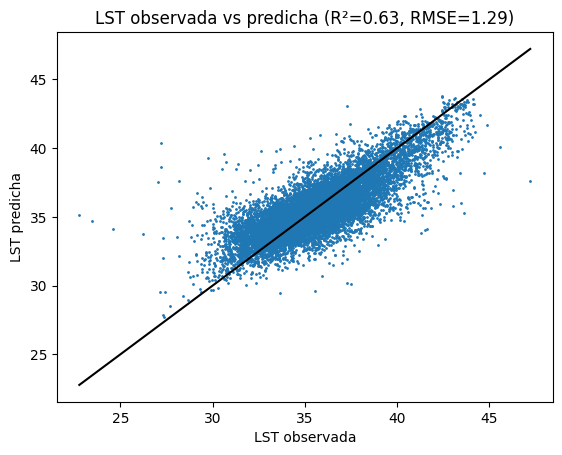

In [56]:
plt.figure()
plt.scatter(y_test, y_pred, s=1)  
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color="black")
plt.xlabel("LST observada")
plt.ylabel("LST predicha")
plt.title(f"LST observada vs predicha (R²={r2:.2f}, RMSE={rmse:.2f})")
plt.show()


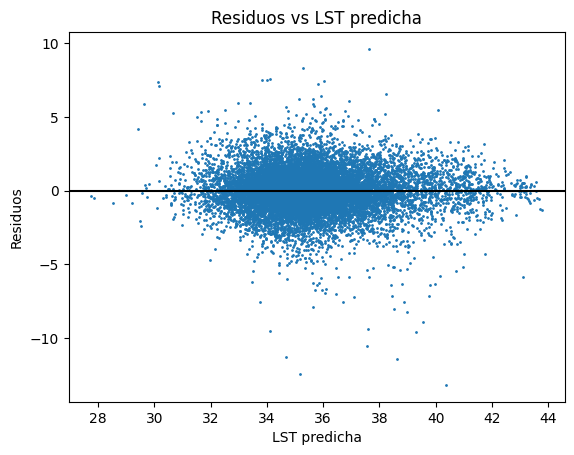

In [57]:
# Residuals plot
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals, s=1)
plt.axhline(0, color='black')
plt.xlabel("LST predicha")
plt.ylabel("Residuos")
plt.title("Residuos vs LST predicha")
plt.show()


In [58]:
# Save trained model
joblib.dump(rf_model, os.path.join(lst_prediction_folder, "rf_model_bologna.pkl"))

['../../../datos-notebooks/3.global-data-cba/LST-prediction/rf_model_bologna.pkl']

## Applying RF model in all the city

In [59]:
print(X.columns.tolist())


['Vegetación densa', 'Vegetación dispersa', 'Altura de vegetación', 'Área construida', 'Altura de edificación', 'Pendiente']


In [60]:
# Predictor order (MUST match training)
predictor_order = ['Vegetación densa', 'Vegetación dispersa', 'Altura de vegetación', 'Área construida', 'Altura de edificación', 'Pendiente']

# Read rasters using 'rasters' dict
arrays = []
meta = None

for name in predictor_order:
    path = rasters[name]   # get path from existing dict
    with rasterio.open(path) as src:
        arr = src.read(1)
        arrays.append(arr)
        if meta is None:
            meta = src.meta.copy()

stack = np.stack(arrays, axis=-1)  # (rows, cols, n_features)


# Mask nodata pixels
nodata_mask = np.any(np.isnan(stack), axis=-1)


# Reshape for model prediction
nrows, ncols, nbands = stack.shape
X_map = stack.reshape(-1, nbands)

valid = ~nodata_mask.ravel()
X_valid = X_map[valid]

# Predict LST
y_map = np.full(X_map.shape[0], np.nan)   # allocate output
y_map[valid] = rf_model.predict(X_valid) # calls the trained model

# Back to raster shape
lst_pred = y_map.reshape(nrows, ncols)

# Save raster
meta.update(dtype="float32", count=1, nodata=np.nan)

out_path = os.path.join(lst_prediction_folder, "LST_predicted_RF.tif")

with rasterio.open(out_path, "w", **meta) as dst:
    dst.write(lst_pred.astype("float32"), 1)
    

C:\Users\guada\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


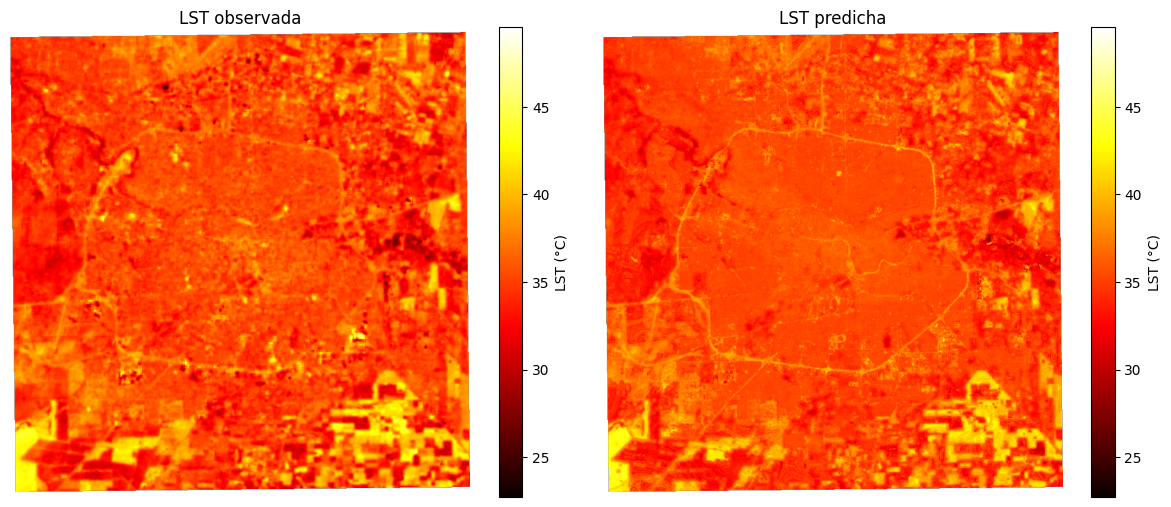

In [61]:
# Plot observed vs predicted LST

lst_predicted_path = os.path.join(lst_prediction_folder, "LST_predicted_RF.tif")

with rasterio.open(lst_clipped_path) as src:
    lst_observed = src.read(1)

with rasterio.open(lst_predicted_path) as src:
    lst_pred = src.read(1)
    
vmin = np.nanmin(lst_observed)
vmax = np.nanmax(lst_observed)

# Plot 
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(lst_observed, vmin=vmin, vmax=vmax, cmap="hot")  # thermal colormap
plt.colorbar(label="LST (°C)")
plt.title("LST observada")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lst_pred, vmin=vmin, vmax=vmax, cmap="hot")  # same colormap
plt.colorbar(label="LST (°C)")
plt.title("LST predicha")
plt.axis("off")

plt.tight_layout()
plt.show()
